In [3]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

from pipeline.obstacle_avoidance_processing import AvoidanceProcessing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [ ]:
light = pd.read_hdf(r"D:\obstacle_avoidance\recordings\data_h5\oa_df_051024.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\recordings\data_h5\dark_oa_df_051024.h5")
dark = dark[dark.task == 'oadark']

G8CK = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
G8CK1 = light[light['animal'].isin(['G8CK1RT','G8CK1LT', 'G8CK1TT', 'G8CK1LN'])]

In [ ]:
light = pd.read_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_oa.h5')

In [ ]:
G8CK1.date.unique()

In [ ]:
G8CK.date.unique()

In [ ]:
G8CK_oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_oa.json",'blank')
G8CK_oa_session.gather_session_df('obstacle',6)
G8CK_oa_df = G8CK_oa_session.df
df_tortuosity(G8CK_oa_df)
G8CK_oa_df = assign_date_index(G8CK_oa_df)

In [ ]:
long,_,_ = create_df_by_type(G8CK_oa_df)

In [ ]:
G8CK1_oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_oa.json",'blank')
G8CK1_oa_session.gather_session_df('obstacle',6)
G8CK1_oa_df = G8CK1_oa_session.df
df_tortuosity(G8CK1_oa_df)
G8CK1_oa_df = assign_date_index(G8CK1_oa_df)

In [ ]:
oa_session = plot_oa(r'D:\obstacle_avoidance\metadata\J701\oa_J701.json','blank')
oa_session.gather_session_df('obstacle',6)
J701_df = oa_session.df

In [ ]:
oa_session = plot_oa(r'D:\obstacle_avoidance\metadata\J701\oa_J701.json','blank')
oa_session.gather_session_df('obstacle',6)
J701_df = oa_session.df

In [ ]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\J701_704\J704_oadark.json",'blank')
oa_session.gather_session_df('obstacle',6)
J704_df = oa_session.df

In [ ]:
oa_session = plot_oa(r'D:\obstacle_avoidance\metadata\SFN\J701_training.json','blank')
oa_session.trial_min_df(training_ses=True)
J701_train_trialpermin_df = oa_session.trialpermin_df

In [ ]:
oa_session = plot_oa(r'd:\obstacle_avoidance\metadata\SFN\G8CK_train.json','blank')
oa_session.trial_min_df(training_ses=True)
G8CK_train_trialpermin_df = oa_session.trialpermin_df

In [ ]:
G8CK1_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_train.json",'blank')
G8CK1_train.trial_min_df(training_ses=True)
G8CK1_train_trialpermin_df = G8CK1_train.trialpermin_df

G8CK1_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_oa.json",'blank')
G8CK1_oa.gather_session_df('obstacle',6)
G8CK1_oa_df = G8CK1_oa.df
G8CK1_oa_df = assign_date_index(G8CK1_oa_df)
df_tortuosity(G8CK1_oa_df)
G8CK1_oa.trial_min_df(training_ses=False)
G8CK1_oa_trialpermin_df = G8CK1_oa.trialpermin_df


In [4]:
G8CK1_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_train.json",'blank')
G8CK1_train.gather_session_df('non_obstalce',6)
G8CK1_train_df = G8CK1_train.df
df_tortuosity(G8CK1_train_df)
G8CK1_train_df = assign_date_index(G8CK1_train_df,train=True)
start(G8CK1_train_df)

In [ ]:
G8CK_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_train.json",'blank')
G8CK_train.trial_min_df(training_ses=True)
G8CK_train_trialpermin_df = G8CK_train.trialpermin_df

G8CK_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_oa.json",'blank')
G8CK_oa.gather_session_df('obstacle',6)
G8CK_oa_df = G8CK_oa.df
G8CK_oa_df = assign_date_index(G8CK_oa_df)
df_tortuosity(G8CK_oa_df)
G8CK_oa.trial_min_df(training_ses=False)
G8CK_oa_trialpermin_df = G8CK_oa.trialpermin_df

In [5]:
G8CK_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_train.json",'blank')
G8CK_train.gather_session_df('non_obstalce',6)
G8CK_train_df = G8CK_train.df
df_tortuosity(G8CK_train_df)
G8CK_train_df = assign_date_index(G8CK_train_df,train=True)
start(G8CK_train_df)


In [ ]:
J701_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J701_train.json",'blank')
J701_train.trial_min_df(training_ses=True)
J701_train_trialpermin_df = J701_train.trialpermin_df

J701_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J701_oa.json",'blank')
J701_oa.gather_session_df('obstacle',6)
J701_oa_df = J701_oa.df
J701_oa_df = assign_date_index(J701_oa_df)
df_tortuosity(J701_oa_df)
J701_oa.trial_min_df(training_ses=False)
J701_oa_trialpermin_df = J701_oa.trialpermin_df

In [6]:
J701_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J701_train.json",'blank')
J701_train.gather_session_df('non_obstalce',6)
J701_train_df = J701_train.df
df_tortuosity(J701_train_df)
J701_train_df = assign_date_index(J701_train_df,train=True)
start(J701_train_df)

In [42]:
light_train.index

Int64Index([ 402,  403,  404,  405,  406,  407,  408,  409,  410,  411,
            ...
            9638, 9639, 9640, 9641, 9642, 9643, 9644, 9645, 9646, 9647],
           dtype='int64', length=9246)

In [41]:
light_train.index.astype(float)

TypeError: float() argument must be a string or a number, not 'type'

In [40]:
light_train.index = light_train.index.astype(float)

TypeError: float() argument must be a string or a number, not 'type'

In [ ]:
light_train = light_train.astype({"index": float, "orginal_index": float})

In [7]:
light_train = pd.concat([G8CK1_train_df,G8CK_train_df,J701_train_df])

In [9]:
light_train= light_train.reset_index()
light_train = light_train[light_train.date_index >= -4]
light_train = light_train.drop(light_train.filter(regex='likelihood').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='resample').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='mean').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='level').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='poke').columns,axis = 1)

In [44]:
light_train.index = light_train.index

TypeError: reindex() missing 1 required positional argument: 'target'

In [56]:
light_train= light_train.reset_index()

In [59]:
light_train = light_train.drop(light_train.filter(regex='level').columns,axis = 1)

In [62]:
light_train

,index,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,rightear_y,spine_x,...,dist,time,orginal_index,ts_inds,tortuosity,linearity,date_index,start,angle_to_rightport,angle_to_leftport
0,0,"[49590.998553, 49591.015078, 49591.031961, 495...","[220, 221, 222, 223, 224, 225, 226, 227, 228, ...","[115.79057312011719, 115.79057312011719, 115.7...","[269.81658935546875, 269.81658935546875, 269.8...","[123.33619691724276, 123.28783529765101, 123.1...","[281.67058474842224, 281.6322270551026, 281.55...","[127.59528988135827, 127.55439713529546, 127.4...","[265.570122090993, 265.51655280281136, 265.414...","[134.946504127007, 134.90431736327338, 134.828...",...,43.969170,3.350000,0,"[121, 122, 123, 124, 125, 126, 127, 128, 129, ...",1.036012,0.965239,-4.0,top,NaN,NaN
1,1,"[49594.366156, 49594.382758, 49594.399449, 495...","[[422, 423, 424, 425, 426, 427, 428, 429, 430,...","[680.4433325672665, 680.473078964103, 680.5256...","[287.1209508921203, 287.1224708451756, 287.123...","[684.1037428947958, 684.118228020649, 684.1452...","[266.02813643822157, 266.0595746761346, 266.10...","[672.5783653566649, 672.6855956046752, 672.881...","[278.4837833801569, 278.5932239153842, 278.788...","[671.6712962476241, 671.7754859620189, 671.959...",...,54.500752,2.916667,1,"[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 8...",1.285167,0.778109,-4.0,bottom,NaN,NaN
2,2,"[49597.300249, 49597.317337, 49597.334515, 495...","[598, 599, 600, 601, 602, 603, 604, 605, 606, ...","[115.9450454711914, 115.9450454711914, 115.945...","[266.990234375, 266.990234375, 266.990234375, ...","[119.39475468725875, 119.34660496315438, 119.2...","[284.1772076040427, 284.1519088534872, 284.097...","[127.21170736136347, 127.12255997864679, 126.9...","[269.21410369271774, 269.12650599158763, 268.9...","[133.53480875185926, 133.46882919673587, 133.3...",...,44.310491,2.916667,2,"[87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 9...",1.048570,0.953680,-4.0,top,NaN,NaN
3,3,"[49600.234624, 49600.251622, 49600.268915, 496...","[[774, 775, 776, 777, 778, 779, 780, 781, 782,...","[679.9324340820312, 679.9324340820312, 679.932...","[282.5118103027344, 282.5118103027344, 282.511...","[684.4121322663807, 684.4577823599678, 684.544...","[263.88956655860693, 263.9267455899585, 263.99...","[675.8674054319687, 675.8553581987572, 675.825...","[278.75751450821053, 278.8404107281136, 278.98...","[674.6058671631189, 674.5841898102511, 674.534...",...,46.022685,3.583333,3,"[124, 125, 126, 127, 128, 129, 130, 131, 132, ...",1.044885,0.957044,-4.0,top,NaN,NaN
4,4,"[49603.836121, 49603.8528, 49603.86944, 49603....","[990, 991, 992, 993, 994, 995, 996, 997, 998, ...","[111.75675864112694, 111.7503823061756, 111.73...","[277.47056724973925, 277.5449567224706, 277.68...","[127.74960565753844, 127.72786561400328, 127.6...","[275.0111130511316, 275.0618342772028, 275.156...","[117.30119860721179, 117.221631555211, 117.066...","[256.3392139297796, 256.4134330998946, 256.559...","[133.6070291186816, 133.51206819530074, 133.32...",...,44.641101,3.900000,4,"[142, 143, 144, 145, 146, 147, 148, 149, 150, ...",1.019858,0.980529,-4.0,bottom,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9241,133,"[46326.609318, 46326.626393, 46326.642675, 463...","[[85822, 85823, 85824, 85825, 85826, 85827, 85...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[656.65966796875, 657.4611206054688, 658.33752...","[249.3760223388672, 248.87884521484375, 249.88...","[647.5926513671875, 649.254638671875, 649.3682...","[263.96429443359375, 264.6365966796875, 265.05...","[642.603271484375, 643.7571411132812, 644.6414...",...,NaN,NaN,133,"[55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 6...",1.227684,0.814542,-1.0,bottom,NaN,NaN
9242,134,"[46329.393689, 46329.410368, 46329.42702, 4632...","[85989, 85990, 85991, 85992, 85993, 85994, 859...","[115.02080535888672, 113.87374877929688, 99.81...","[210.86387634277344, 2

In [ ]:
i = 0
dfdone = False #if True, all keys in the .h5 file are successfully loaded.
srl = [] #df series object list
while dfdone == False:
    #print(i) #this is to see if code is working properly.
    try: #check whether current i value exists in the keys of the .h5 file
        sdfr = pd.read_hdf('df.h5', key='table_%i'%i) #Current series object
        srl.append(sdfr) #append each series to a list to create the dataframe in the end.
        i += 1 #increment i by 1 after loading the series object
    except: #if an error occurs, current i value exceeds the number of keys, all keys are loaded.
        dfdone = True #Terminate the while loop.

df = pd.concat(srl) #Generate the dataframe from the list of series objects.

In [ ]:
pd.concat([G8CK1_train_df,G8CK_train_df,J701_train_df])

In [69]:
G8CK1_train_df.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\G8CK1_train_df.h5','w')
G8CK_train_df.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\G8CK_train_df.h5','w')
J701_train_df.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\J701_train_df.h5','w')

In [24]:
light_train.columns[0]

'index'

In [33]:
light_train.index =  light_train.index.astype(float)

TypeError: float() argument must be a string or a number, not 'type'

In [35]:
light_train.index

Int64Index([ 402,  403,  404,  405,  406,  407,  408,  409,  410,  411,
            ...
            9638, 9639, 9640, 9641, 9642, 9643, 9644, 9645, 9646, 9647],
           dtype='int64', length=9246)

In [1]:
light_train = pd.concat([G8CK1_train_df,G8CK_train_df,J701_train_df])
#light_train = light_train.drop(columns='level_0')
light_train= light_train.reset_index()
light_train = light_train[light_train.date_index >= -4]
light_train = light_train.drop(light_train.filter(regex='likelihood').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='resample').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='mean').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='level').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='poke').columns,axis = 1)
light_train = light_train.astype({"index": float, "orginal_index": float})
#light_train.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_train.h5','w')
batch_size = 1000
for i, df_chunk in light_train.groupby(np.arange(light_train.shape[0]) // batch_size):
    df_chunk.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_train.h5','table', complib= 'blosc:lz4', mode='a')


NameError: name 'pd' is not defined

In [ ]:
light_train = light_train.drop(light_train.filter(regex='likelihood').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='resample').columns,axis = 1)

In [ ]:
joint = pd.concat([light_train,light])
joint = joint.drop(columns='level_0')
joint= joint.reset_index()

In [ ]:
sns.lineplot(data =joint,x = 'date_index',y='time' )

In [ ]:
light_trial_permin[(light_trial_permin.date_index==-1) &(light_trial_permin.animal=='J701RN')]

In [ ]:
light_trial_permin[(light_trial_permin.date_index==-4) &(light_trial_permin.animal=='J701RN')]

In [ ]:
train_J701RT = light_train[(light_train.date_index==-1) &(light_train.animal=='J701RN')&(light_train.odd=='right')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
x = flatten_list_of_arrays(train_J701RT.ts_nose_x_cm.to_numpy())
y = flatten_list_of_arrays(train_J701RT.ts_nose_y_cm.to_numpy())
plt.hist2d(x =x ,y = y,bins=[48,23],range=[[9,57],[8,31]])

In [ ]:
x = flatten_list_of_arrays(train_J701RT.ts_nose_x_cm.to_numpy())
y = flatten_list_of_arrays(train_J701RT.ts_nose_y_cm.to_numpy())
arr,_,_ = np.histogram2d(x =x ,y = y,bins=[48,23],range=[[9,57],[8,31]])
arr[arr<=10 ]= 0
arr[arr>=10 ]= 1 
plt.imshow(arr)

In [ ]:
arr[arr<=30 ]= 0
arr[(30<=arr) & (arr>=60) ]= .5
arr[arr>=60 ]= 1 


In [ ]:
arr[arr<=30 ]= 0

arr[arr>=30 ]= 1 

In [ ]:
arr

In [ ]:
plt.imshow(arr)

In [ ]:
x = flatten_list_of_arrays(train_J701RT.ts_nose_x_cm.to_numpy())
y = flatten_list_of_arrays(train_J701RT.ts_nose_y_cm.to_numpy())
plt.hist2d(x =x ,y = y,bins=[48,23],range=[[9,57],[8,31]])

In [ ]:

sl, matx, maty = create_streamlines(train_J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:
x = flatten_list_of_arrays(train_J701RT.ts_nose_x_cm.to_numpy())
y = flatten_list_of_arrays(train_J701RT.ts_nose_y_cm.to_numpy())
plt.hist2d(x =x ,y = y,bins=[48,23],range=[[9,57],[8,31]])

In [ ]:
train_J701RT = light_train[(light_train.date_index==-4) &(light_train.animal=='J701RN')&(light_train.odd=='right')&(light_train.start=='bottom')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
x = flatten_list_of_arrays(train_J701RT.ts_nose_x_cm.to_numpy())
y = flatten_list_of_arrays(train_J701RT.ts_nose_y_cm.to_numpy())
arr,_,_ = np.histogram2d(x =x ,y = y,bins=[48,23],range=[[9,57],[8,31]])
arr[arr<=15 ]= 0
arr[arr>=15 ]= 1 
plt.imshow(arr)

In [ ]:

sl, matx, maty = create_streamlines(train_J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:
dictists = {key: [] for key in ['animal','date','date_index','trialpermin','task','session_min',"trials",'trial_time']}
        for date, date_df in self.df .groupby(['date_index']):
            for ani, ani_df in date_df.groupby(['animal']):
                for task,task_df in ani_df.groupby('task'):
                    dictists['animal'].append(ani)
                    dictists['date_index'].append(date)
                    trialpermin = (len(task_df))/(task_df.len.sum()/60/60)
                    dictists['trialpermin'].append(trialpermin)
                    dictists['task'].append(task_df.task.unique()[0])
                    dictists['date'].append(task_df.date.unique()[0])
                    dictists['session_min'].append(task_df.len.sum()/60/60)
                    dictists['trials'].append(len(task_df))
                    dictists['trial_time'].append(task_df.len.median()/60)

        trialpermin_df = pd.DataFrame.from_dict(dictists)
        self.trialpermin_df = trialpermin_df


In [ ]:
df = light
dictists = {key: [] for key in ['animal','date','date_index','cluster',"start",'odd','trials']}
for date_id,date_id_df in df.groupby(['date_index']):
    for ani, ani_df in date_id_df.groupby(['animal']):
        for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
            for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
                for start,start_df in cluster_df.groupby('start'):
                    for odd,odd_df in start_df.groupby('odd'):
                        dictists['animal'].append(ani)
                        dictists['date_index'].append(date)
                        dictists['date'].append(odd_df.date.unique()[0])
                        dictists['trials'].append(len(odd_df))
                        dictists['cluster'].append(odd_df.obstacle_cluster.unique()[0])
                        dictists['start'].append(odd_df.start.unique()[0])
                        dictists['odd'].append(odd_df.odd.unique()[0])



                        




In [ ]:
cluster = pd.DataFrame.from_dict(dictists)

In [ ]:
cluster

In [ ]:
sns.histplot(data = cluster,x = 'trials')

In [ ]:
sns.histplot(data = cluster,x = 'trials',hue='animal')

In [ ]:

sl, matx, maty = create_streamlines(J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))
np.mean(fdist_avg)

In [70]:
J701RT = light[(light.date_index==5.0) &(light.animal=='J701LT')&(light.obstacle_cluster==0)&(light.odd=='right')&(light.start=='top')]
fig,ax = plt.subplots()
plot_arena(J701RT,ax)
plot_orginal_obstacle(J701RT,ax,0)
for ind, row in J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

NameError: name 'light' is not defined

In [ ]:

sl, matx, maty = create_streamlines(J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))
np.mean(fdist_avg)

In [ ]:
J701RT = light[(light.date_index==0.0) &(light.animal=='J701LT')&(light.obstacle_cluster==0)&(light.odd=='right')&(light.start=='top')]
fig,ax = plt.subplots()
plot_arena(J701RT,ax)
plot_orginal_obstacle(J701RT,ax,0)
for ind, row in J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:

sl, matx, maty = create_streamlines(J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))
np.mean(fdist_avg)

In [ ]:

sl, matx, maty = create_streamlines(J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))
np.mean(fdist_avg)

In [ ]:
J701RT = light[(light.date_index==6.0) &(light.obstacle_cluster==0)&(light.odd=='right')&(light.start=='top')]
fig,ax = plt.subplots()
plot_arena(J701RT,ax,outer=True)
plot_orginal_obstacle(J701RT,ax,0)
for ind, row in J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
df = light
dictists = {key: [] for key in ['animal','date','date_index','cluster',"start",'odd','trials']}
for date_id,date_id_df in df.groupby(['date_index']):
    for ani, ani_df in date_id_df.groupby(['animal']):
        for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
            for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
                for start,start_df in cluster_df.groupby('start'):
                    for odd,odd_df in start_df.groupby('odd'):
                        dictists['animal'].append(ani)
                        dictists['date_index'].append(date)
                        dictists['date'].append(odd_df.date.unique()[0])
                        dictists['trials'].append(len(odd_df))
                        dictists['cluster'].append(odd_df.obstacle_cluster.unique()[0])
                        dictists['start'].append(odd_df.start.unique()[0])
                        dictists['odd'].append(odd_df.odd.unique()[0])


In [ ]:
J701RN = light[light.animal == 'J701RN']
df = J701RN
dictists = {key: [] for key in ['animal','date_index','obstacle_cluster',"trials",'fdist','start','odd']}
for date_id,date_id_df in df.groupby(['date_index']):
    for ani, ani_df in date_id_df.groupby(['animal']):
        for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
            for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
                for start,start_df in cluster_df.groupby('start'):
                    for odd,odd_df in start_df.groupby('odd'):
                        dictists['animal'].append(ani)
                        dictists['date_index'].append(odd_df.date_index.unique()[0])
                        dictists['trials'].append(len(odd_df))
                        dictists['obstacle_cluster'].append(odd_df.obstacle_cluster.unique()[0])
                        dictists['start'].append(odd_df.start.unique()[0])
                        dictists['odd'].append(odd_df.odd.unique()[0])
                        if len(odd_df) >=4:
                            sl, matx, maty = create_streamlines(odd_df,'ts_nose_x_cm','ts_nose_y_cm')
                            fdist_avg = []
                            for i,row in enumerate(sl):
                                fdist_list = []
                                for traj in sl: 
                                    avg_fdist = frdist(sl[i],traj)
                                    fdist_list.append(avg_fdist)
                                fdist_avg.append(np.nanmean(fdist_list))
                            dictists['fdist'].append(np.mean(fdist_avg))
                            
                        else:
                            dictists['fdist'].append(np.nan)



            

In [1427]:
def compute_frenchet_distance(df):
    """returns df each row is the average frenchet distance of a cluster by direction, start, animal, and date_index"""
    dictists = {key: [] for key in ['animal','date_index','obstacle_cluster',"trials",'fdist','start','odd']}
    df = df
    for date_id,date_id_df in df.groupby(['date_index']):
        for ani, ani_df in date_id_df.groupby(['animal']):
            for cluster,cluster_df in tqdm(ani_df.groupby('obstacle_cluster')):
                for start,start_df in cluster_df.groupby('start'):
                    for odd,odd_df in start_df.groupby('odd'):
                        dictists['animal'].append(ani)
                        dictists['date_index'].append(odd_df.date_index.unique()[0])
                        dictists['trials'].append(len(odd_df))
                        dictists['obstacle_cluster'].append(odd_df.obstacle_cluster.unique()[0])
                        dictists['start'].append(odd_df.start.unique()[0])
                        dictists['odd'].append(odd_df.odd.unique()[0])
                        if len(odd_df) >=4:
                            sl, matx, maty = create_streamlines(odd_df,'ts_nose_x_cm','ts_nose_y_cm')
                            fdist_avg = []
                            for i,row in enumerate(sl):
                                fdist_list = []
                                for traj in sl: 
                                    avg_fdist = frdist(sl[i],traj)
                                    fdist_list.append(avg_fdist)
                                fdist_avg.append(np.nanmean(fdist_list))
                            dictists['fdist'].append(np.mean(fdist_avg))
                        else:
                            dictists['fdist'].append(np.nan)
    f_dist_df = pd.DataFrame.from_dict(dictists)
    return f_dist_df
    

In [1428]:
J701RN = light[light.animal == 'J701RN']
J701RN_fdist = compute_frenchet_distance(J701RN)


100%|██████████| 6/6 [00:14<00:00,  2.47s/it]


In [1429]:
J701RN_fdist

,animal,date_index,obstacle_cluster,trials,fdist,start,odd
0,J701RN,0.0,0,3,NaN,bottom,left
1,J701RN,0.0,0,5,11.451511,bottom,right
2,J701RN,0.0,0,7,3.716556,top,left
3,J701RN,0.0,0,11,4.963167,top,right
4,J701RN,0.0,1,2,NaN,bottom,left
...,...,...,...,...,...,...,...
140,J701RN,6.0,4,1,NaN,bottom,left
141,J701RN,6.0,4,9,6.941334,bottom,right
142,J701RN,6.0,4,8,3.002195,top,left
143,J701RN,6.0,5,6,6.032999,bottom,right


In [ ]:
sns.boxplot(data=J701RN_fdist,x='date_index',y='fdist')

In [1439]:
long

,animal,date_index,obstacle_cluster,trials,fdist,start,odd
3,J701RN,0.0,0,11,4.963167,top,right
26,J701RN,1.0,0,7,5.577487,top,right
45,J701RN,2.0,0,7,4.049384,top,right
65,J701RN,3.0,0,5,5.257217,top,right
83,J701RN,4.0,0,10,4.680083,top,right
107,J701RN,5.0,0,7,3.795749,top,right
130,J701RN,6.0,0,1,NaN,top,right
6,J701RN,0.0,1,2,NaN,top,left
29,J701RN,1.0,1,4,4.720740,top,left
46,J701RN,2.0,1,4,5.830906,top,left


10


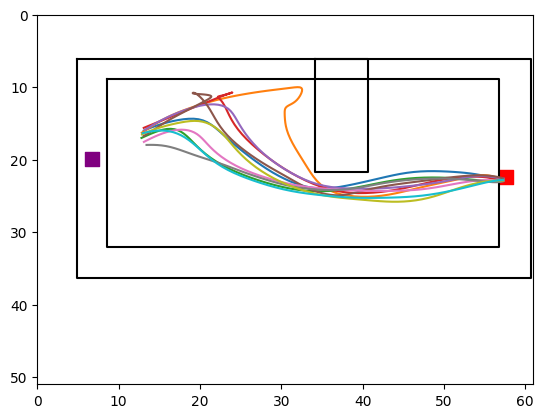

In [1479]:
J701RN = light[(light.date_index==6.0) &(light.obstacle_cluster==1)&(light.odd=='left')&(light.start=='top')&(light.animal=='J701RN') ]
fig,ax = plt.subplots()
plot_arena(J701RN,ax,outer=True)
plot_orginal_obstacle(J701RN,ax,0)
print(len(J701RN))
for ind, row in J701RN.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
J701RN = test[(test.obstacle_cluster==0)&(test.odd=='right')&(test.start=='top')&(test.animal=='J701RN') ]

In [1433]:
long, short, middle = create_df_by_type(J701RN_fdist)

In [ ]:
test.trials.hist()

In [1434]:
long

,animal,date_index,obstacle_cluster,trials,fdist,start,odd
3,J701RN,0.0,0,11,4.963167,top,right
26,J701RN,1.0,0,7,5.577487,top,right
45,J701RN,2.0,0,7,4.049384,top,right
65,J701RN,3.0,0,5,5.257217,top,right
83,J701RN,4.0,0,10,4.680083,top,right
107,J701RN,5.0,0,7,3.795749,top,right
130,J701RN,6.0,0,1,NaN,top,right
6,J701RN,0.0,1,2,NaN,top,left
29,J701RN,1.0,1,4,4.720740,top,left
46,J701RN,2.0,1,4,5.830906,top,left


<AxesSubplot: xlabel='date_index', ylabel='fdist'>

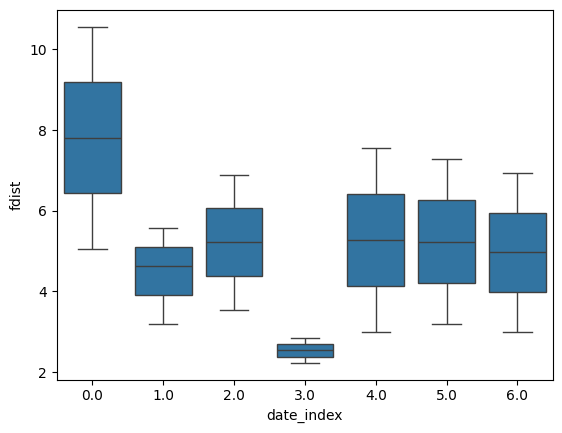

In [1464]:
sns.boxplot(data=J701RN_fdist[J701RN_fdist.obstacle_cluster == 4],x='date_index',y='fdist')

In [ ]:
J701RN = light[light.animal == 'J701RN']
dictists = {key: [] for key in ['animal','date_index','obstacle_cluster',"trials",'fdist']}
for date, date_df in J701RN.groupby(['date_index']):
    for ani, ani_df in date_df.groupby(['animal']):
        for task,task_df in ani_df.groupby('task'):
            



In [ ]:

sl, matx, maty = create_streamlines(J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:
J701RT = light[(light.date_index==0.0) &(light.obstacle_cluster==0)&(light.odd=='right')&(light.start=='top')]
fig,ax = plt.subplots()
plot_arena(J701RT,ax,outer=True)
plot_orginal_obstacle(J701RT,ax,0)
for ind, row in J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:

sl, matx, maty = create_streamlines(J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:
train_J701RT = light_train[(light_train.date_index==-4) &(light_train.animal=='J701RN')&(light_train.odd=='right')&(light_train.start=='bottom')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
light = pd.concat([J701_oa_df,G8CK1_oa_df,G8CK_oa_df])
light = light.drop(columns='level_0')
light= light.reset_index()
light = light[(light.date_index <=6)]
sns.barplot(data =light,x = 'date_index',y='linearity' )
plt.ylim(.7,1)


In [ ]:
test = G8CK1_train_df[G8CK1_train_df.linearity<.7].sample(1)
fig,ax = plt.subplots()
plot_arena(test,ax)
#plot_orginal_obstacle(test,ax,test.obstacle_cluster.to_numpy()[0])
for ind,row in test.iterrows():
    ax.plot(row.ts_nose_x_cm,row.ts_nose_y_cm)

In [ ]:
light_trial_permin = pd.concat([J701_oa_trialpermin_df,J701_train_trialpermin_df,G8CK_oa_trialpermin_df,G8CK_train_trialpermin_df,G8CK1_oa_trialpermin_df,G8CK1_train_trialpermin_df])
light_trial_permin = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
sns.lineplot(data =light_trial_permin,x = 'date_index',y='trials' ,errorbar='se',err_style='bars')

In [ ]:

from matplotlib.gridspec import GridSpec

In [ ]:
light_trial_permin = pd.concat([J701_oa_trialpermin_df,J701_train_trialpermin_df,G8CK_oa_trialpermin_df,G8CK_train_trialpermin_df,G8CK1_oa_trialpermin_df,G8CK1_train_trialpermin_df])
light_trial_permin.to_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5", 'w')

In [ ]:
light_trial_permin = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5")

In [ ]:
light_trial_permin[(light_trial_permin.date_index == 0.0 ) 

In [ ]:
light_trial_permin

In [ ]:
light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)]

In [ ]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Average Trial Time (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trial_time' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trial_time',errorbar = 'se')


In [ ]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Average Trial Time (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trials' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trials',errorbar = 'se')


In [ ]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Average Trial Time (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trial_time' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.boxplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trial_time')


In [ ]:
from scipy.stats import f_oneway
from scipy.stats import tukey_hsd
f_oneway(line[line.date_index==0].trial_time.to_numpy(),line[line.date_index==3].trial_time.to_numpy(),line[line.date_index==6].trial_time.to_numpy())
res = tukey_hsd(line[line.date_index==0].trial_time.to_numpy(),line[line.date_index==3].trial_time.to_numpy(),line[line.date_index==6].trial_time.to_numpy())

In [ ]:
f_oneway(line[line.date_index==0].trial_time.to_numpy(),line[line.date_index==3].trial_time.to_numpy(),line[line.date_index==6].trial_time.to_numpy())

In [ ]:
print(res)

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import bootstrap

In [ ]:
tukey = pairwise_tukeyhsd(endog = bar['trialpermin'],groups=bar['date_index'])
print(tukey)

In [ ]:
res = bootstrap(data, np.std, confidence_level=0.9,
                random_state=rng)

In [ ]:
tukey = pairwise_tukeyhsd(endog = line['trialpermin'],groups=line['date_index'])
print(tukey)

In [ ]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Trials per minute')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trialpermin' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trialpermin',errorbar = 'se')

In [ ]:
tukey = pairwise_tukeyhsd(endog = line['trialpermin'],groups=line['date_index'])
print(tukey)

In [ ]:
distance_calcs(light)
deveation(light)
heading_calcs(light)

In [ ]:
lateral_error(light)

In [ ]:
light.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_oa.h5','w')

In [ ]:
light.lateral_error

In [ ]:
def edge_outliers(array,thresh):
    "take out edege outliers in interpolations"
    diff = np.diff(array)
    if np.abs(diff[-1]) > thresh:
        array[-1] = array[-2]
    else:
        array = array
    return array

In [ ]:

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = long[long.date_index==1]
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)




In [ ]:
angle_mean

In [ ]:
angle_mean[-1] = angle_mean[-2]

In [ ]:
edge_outliers(angle_mean,2)

In [ ]:
np.diff(angle_mean)

In [ ]:
df = long[long.date_index==0]
df = drop_nans_in_columns(df,'ts_zero_out_angle_to_corner')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

NameError: name 'long' is not defined

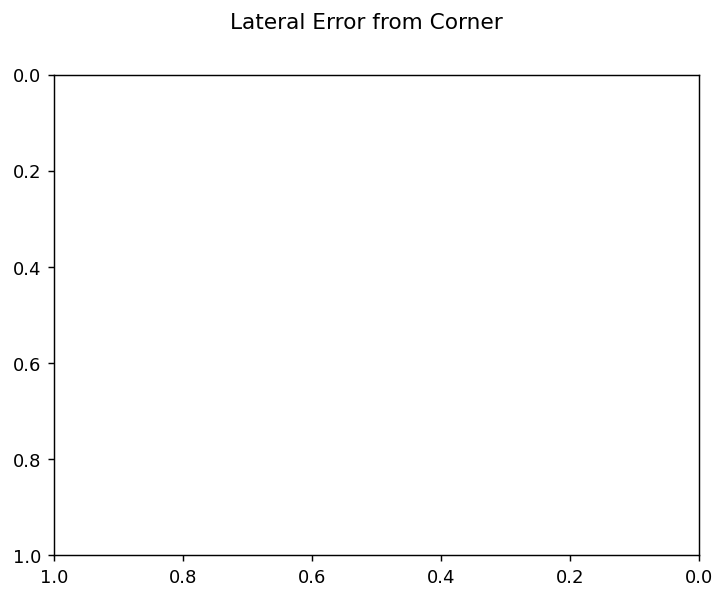

In [71]:

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = long
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)

In [ ]:

xnew =  np.arange(-1, 20, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = long
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)

ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1.5)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    #median, q1, q3, iqr = calculate_quartiles(angle_array)

In [ ]:
df = long
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    #median, q1, q3, iqr = calculate_quartiles(angle_array)

In [ ]:
df = long
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)

In [ ]:
df_tortuosity(li)

In [ ]:
deeplabcut.extract_frames(path_config_file, 'automatic', 'kmeans', crop = False, userfeedback = False)

In [ ]:
row.ts_nose_x_cm

In [ ]:
train_J701RT = light_train[(light_train.date_index==-4) &(light_train.animal=='J701NN')&(light_train.odd=='left')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
light_train.time

In [ ]:
train_J701RT.time

In [ ]:
train_J701RT.date.unique()

In [ ]:
train_G8CK1RT = pd.read_hdf(r"D:\obstacle_avoidance\recordings\051123\G8CK1RT\oa\non_obstacleG8CK1RT_051123_oa.h5")

In [ ]:
train_G8CK1RT[train_G8CK1RT.odd=='right']

In [ ]:
from frechetdist import frdist
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
from streamline_clustering.clustering import pair_elements,create_streamlines

In [ ]:
AveragePointwiseEuclideanMetric()

In [ ]:
df = train_G8CK1RT[train_G8CK1RT.odd=='right']
sl, matx, maty = create_streamlines(df,'ts_nose_x_cm','ts_nose_y_cm')

In [ ]:
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:

df2 = light_train[(light_train.date_index==-1) &(light_train.animal=='G8CK1RT')&(light_train.odd=='right')]
sl, matx, maty = create_streamlines(df2,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:
frdist(sl[0],sl[1])

In [ ]:

fig,ax = plt.subplots()
plot_arena(train_G8CK1RT,ax)
for ind, row in train_G8CK1RT[train_G8CK1RT.odd=='right'].sample(10).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
split_range_into_parts(np.nanmedian(pd.unique(light_train.arenaTL_y_cm)),np.nanmedian(pd.unique(light_train.arenaBL_y_cm)),2)

In [ ]:
start(light_train)

In [ ]:
J701_train_df

In [ ]:
train_J701RT = J701_train_df[(J701_train_df.date_index==-3) &(J701_train_df.animal=='J701RT')&(J701_train_df.odd=='right')&(J701_train_df.start=='top')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
train_J701RT = light_train[(light_train.date_index==-4) &(light_train.animal=='G8CK1RT')&(light_train.odd=='right')&(light_train.start=='top')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:

sl, matx, maty = create_streamlines(train_J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:
train_J701RT = light_train[(light_train.date_index==-1) &(light_train.animal=='G8CK1RT')&(light_train.odd=='right')&(light_train.start=='bottom')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:

sl, matx, maty = create_streamlines(train_J701RT,'ts_nose_x_cm','ts_nose_y_cm')
fdist_avg = []
for i,row in enumerate(sl):
    fdist_list = []
    for traj in sl: 
        avg_fdist = frdist(sl[i],traj)
        fdist_list.append(avg_fdist)
    fdist_avg.append(np.nanmean(fdist_list))

In [ ]:
np.mean(fdist_avg)

In [ ]:
train_J701RT = light_train[(light_train.date_index==-4) &(light_train.animal=='G8CK1RT')&(light_train.odd=='left')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
train_J701RT = light_train[(light_train.date_index==-1) &(light_train.animal=='G8CK1RT')&(light_train.odd=='left')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
train_J701RT = light_train[(light_train.date_index==-1) &(light_train.animal=='G8CK1LN')&(light_train.odd=='right')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.sample(15).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
def  trail_min_df(self):
        # list data path files
        data_path = Path(self.path).expanduser()
        # find date
        hf_list = []
        df =pd.DataFrame()
        for date in self.dates_list:
            use_animals = [k for k,v in self.metadata[date].items()]
            for ani in use_animals:
                for task in os.listdir(data_path / date / ani):
                    h5_paths=[str(i) for i in list((data_path / date / ani/ task).rglob('*.h5'))]
                    raw_h5 = [i for i in h5_paths if 'test' in i]
                    hf_list.append(raw_h5)
        hf_list = list(itertools.chain(*hf_list))
        for h5 in hf_list:
            data = pd.read_hdf(h5)
            df=df.append(data,ignore_index=False)
        self.df=df
        self.df['orginal_index'] = self.df.index
        self.df =self.df.reset_index()

        dictists = {key: [] for key in ['animal','date','date_index','trialpermin','task']}
        for date, date_df in self.df .groupby(['date_index']):
            for ani, ani_df in date_df.groupby(['animal']):
                for task,task_df in ani_df.groupby('task'):
                    dictists['animal'].append(ani)
                    dictists['date_index'].append(date)
                    trialpermin = (len(task_df))/(task_df.len.sum()/60/60)
                    dictists['trialpermin'].append(trialpermin)
                    dictists['task'].append(task_df.task.unique()[0])
        trialpermin_df = pd.DataFrame.from_dict(dictists)



       

In [ ]:
def find_consecutive_repeats2(series):
    result = []
    count = 1
    for i in range(1, len(series)):
        if series[i] == series[i-1]:
            count += 1
        else:
            if count >= 3:
                result.append((i-count, series[i-1]))
            count = 1
    if count >= 3:
        result.append((len(series)-count, series[len(series)-1]))
    return result

In [ ]:
def find_consecutive_repeats(series):

    """
    finds consective repeats in a pd.series
    Used to find trials that have repeat of the same  obstacle location
    """
    consecutive_repeats = []
    count = 1
    prev_value = None

    for index, value in series.iteritems():
        if value == prev_value:
            count += 1
        else:
            if count > 3:
                count = 1
                prev_value = value
            
            count = 1
            prev_value = value

        if count >= 3:
            consecutive_repeats.append((index - count+1, index, value,count))
    
 
    #for count,row in enumerate(consecutive_repeats):
    #    if consecutive_repeats[count][-1] != 3:
    #        del consecutive_repeats[count]
    

    return consecutive_repeats

def create_consective_df_new(df):
        """get df from data of groups of 3 trials that are consecutive """
        con_df = pd.DataFrame()
        copy = df.copy(deep=True)
        copy = copy.reset_index(drop=True)
        for animal,animal_frame in copy.groupby('animal'):
            for date, date_frame in animal_frame.groupby('date'):
                repeats_list = find_consecutive_repeats(date_frame['obstacle_cluster'])
                for i in range(len(repeats_list)):
                    check = date_frame.loc[repeats_list[i][0]:repeats_list[i][1]]
                    #print(np.diff(check['index'].to_numpy()).sum())
                    if np.diff(check['index'].to_numpy()).sum()==2:
                        trial_df = pd.DataFrame()
                        trial_df = trial_df.append(date_frame.loc[repeats_list[i][0]:repeats_list[i][1]])
                        trial_df['consective_inds'] = str(list(range(repeats_list[i][0], repeats_list[i][1]+1)))
                        trial_df['consective_type'] = [1,2,3]
                        con_df = con_df.append(trial_df) 
                    else:
                        continue
                       
        return con_df

In [ ]:
def create_consective_df_new(df):
        """get df from data of groups larger than 3 trials that are consecutive """
        con_df = pd.DataFrame()
        copy = df.copy(deep=True)
        copy = copy.reset_index(drop=True)
        for animal,animal_frame in copy.groupby('animal'):
            for date, date_frame in animal_frame.groupby('date'):
                repeats_list = find_consecutive_repeats(date_frame['obstacle_cluster'])
                for i in range(len(repeats_list)):
                    check = date_frame.loc[repeats_list[i][0]:repeats_list[i][1]]
                    #print(np.diff(check['index'].to_numpy()).sum())
                    
                    trial_df = pd.DataFrame()
                    trial_df = trial_df.append(date_frame.loc[repeats_list[i][0]:repeats_list[i][1]])
                    trial_df['consective_inds'] = str(list(range(repeats_list[i][0], repeats_list[i][1]+1)))
                    trial_df['consective_type'] = list(range( (repeats_list[i][1]+1) - (repeats_list[i][0])))
                    con_df = con_df.append(trial_df) 
                    
                       
        return con_df

In [ ]:
def assign_date_index(df):
    '''assign dates with index 0 == first day'''
    df = df.copy(deep = True)
    date_list = df.date.unique().tolist() 
    date_list = sorted([int(x) for x in date_list])
    date_list = list(map(str, date_list))
    date_list = ['0'+ date for date in date_list]
    index_list = list(range((len(date_list))))
    date_index_dict = dict(zip(date_list,index_list))
    for ind,row in df.iterrows():
        df.at[ind,'date_index']= int(date_index_dict.get(row.date))

    return df




In [ ]:
fig,ax = plt.subplots()
sns.lineplot(data =  light, estimator='median',errorbar = 'se' ,x = 'date_index',y = 'linearity')
plt.xlim(-.5,7.5)
plt.ylim(.6,1)
for date, date_df in light.groupby(['date_index']):
    for ani, animal_df in date_df.groupby(['animal']):
        ax.scatter(date,animal_df.linearity.median(),color = 'grey')

In [ ]:
fig,ax = plt.subplots()
sns.lineplot(data =  light[light['tortuosity']<5], estimator='median',errorbar = 'se' ,x = 'date_index',y = 'linearity')
plt.xlim(-.5,7.5)
plt.ylim(.6,1)
for date, date_df in light[light['tortuosity']<5].groupby(['date_index']):
    for ani, animal_df in date_df.groupby(['animal']):
        ax.scatter(date,animal_df.linearity.median(),color = 'grey')

In [ ]:
fig,ax = plt.subplots()
sns.lineplot(data =  light[light['tortuosity']<5], estimator='mean',errorbar = 'se' ,x = 'date_index',y = 'linearity')
plt.xlim(-.5,7.5)
plt.ylim(.6,1)
for date, date_df in light[light['tortuosity']<5].groupby(['date_index']):
    for ani, animal_df in date_df.groupby(['animal']):
        ax.scatter(date,animal_df.linearity.median(),color = 'grey')

In [1480]:
from scipy.ndimage import gaussian_filter

In [ ]:

xnew =  np.arange(-2, 20, .5)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = long[long.task =='oa']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
    std = np.nanstd(angle_array, axis=0)
    std_error = []
    samplesqrt =np.sqrt(angle_array.shape[0])
    for i in std:
        std_error.append(i/samplesqrt)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, date_angle_median-std_error, date_angle_median + std_error, color='tab:red', alpha=0.3, label='IQR')
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:
test = np.nanstd(angle_array, axis=0)
std_error = []
samplesqrt =np.sqrt(angle_array.shape[0])
for i in test:
    std_error.append(i/samplesqrt)

In [ ]:
angle_array.shape[0]

In [ ]:
angle_array.shape[0]

In [ ]:
np.sqrt(angle_array.shape[0])

In [ ]:
angle_array[:,0]

In [ ]:
sem(angle_array[:,0],nan_policy='omit')

In [ ]:
from scipy.stats import sem

In [ ]:
angle_array.shape

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = J701_df[J701_df.task =='oa']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = dark_long[dark_long.task =='oadark']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = dark[dark.task =='oadark']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = dark_long[dark_long.task =='oadark']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = long
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = long
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 15, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = short
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:
from scipy.stats import gaussian_kde
def normalize_arrays(array):
    min_max_scaler = p.MinMaxScaler() 
    norm_array_of_arrays = min_max_scaler.fit_transform(array.reshape(-1, 1)).flatten() 
    return norm_array_of_arrays   
from sklearn import preprocessing as p 